# 02 — Transformer vs CNN Baseline

Load saved checkpoints for the transformer and the DeepMind CNN, run both
on the held-out test split, and compare accuracy, macro-F1, and hit-rate.
Also visualises attention maps to show which residue positions the transformer
attends to most strongly.

In [ ]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from nucb_transformer.utils.io import load_checkpoint
from nucb_transformer.training.metrics import compute_metrics, confusion_matrix_df, hit_rate

from sklearn.metrics import f1_score
from nucb_transformer.training.metrics import (
    ACTIVITY_CLASSES, hit_rate, bootstrap_hit_rate, spearman_rho, confusion_matrix_df,
)
import numpy as np

from nucb_transformer.data.encoding import tokenize

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from nucb_cnn.utils.io import load_checkpoint as cnn_load_checkpoint



In [ ]:
# to resolve issue w kernel launching from wrong directory(?)
import os
os.chdir('/Users/zahmiriajohnson/repo/AwasthiJohnson_10.C51')

In [ ]:
# # Reconstruct transformer from best checkpoint
# model_trans, ckpt_trans = load_checkpoint('checkpoints/training_trans/epoch_046_acc0.6746.pt')
# print('Saved transformer val metrics:', ckpt_trans.get('metrics', {}))

# # Reconstruct cnn from best checkpoint
# model_cnn, ckpt_cnn = load_checkpoint('checkpoints/training_cnn/epoch_023_acc0.6700.pt')
# print('Saved CNN val metrics:', ckpt_cnn.get('metrics', {}))

# # Run on test set and compute metrics

In [ ]:
# I already did the testing using script/eval....
# and saved the predictions in a csv, so I'll just load that here
cnn_preds_df = pd.read_csv('results/cnn_test_predictions.csv')
trans_preds_df = pd.read_csv('results/trans_test_predictions.csv')

In [8]:
# Def functions to compute metrics for both models
def _to_indices(df):
    labels = np.array([ACTIVITY_CLASSES.index(c) for c in df["activity_level"]])
    preds  = np.array([ACTIVITY_CLASSES.index(c) for c in df["predicted_class"]])
    return preds, labels

def summarize(name, df):
    preds, labels = _to_indices(df)
    accuracy  = float((preds == labels).mean())
    macro_f1  = float(f1_score(labels, preds, average="macro", zero_division=0))
    per_cls   = f1_score(labels, preds, average=None, zero_division=0)
    hr        = hit_rate(preds, labels)
    ci_lo, ci_hi = bootstrap_hit_rate(preds, labels)
    rho       = spearman_rho(preds.astype(float), labels.astype(float))

    print(f"{'='*40}")
    print(f"  {name}  (n={len(df):,})")
    print(f"{'='*40}")
    print(f"  accuracy      {accuracy:.4f}")
    print(f"  macro_f1      {macro_f1:.4f}")
    print(f"  hit_rate      {hr:.4f}  (95% CI: {ci_lo:.4f}–{ci_hi:.4f})")
    print(f"  spearman_rho  {rho:.4f}")
    print()
    for i, cls in enumerate(ACTIVITY_CLASSES):
        print(f"  f1  {cls:<24}  {per_cls[i]:.4f}")
    print()
    print("Confusion matrix (rows=true, cols=predicted):")
    display(confusion_matrix_df(preds, labels))
    print()
    return dict(model=name, accuracy=accuracy, macro_f1=macro_f1,
                hit_rate=hr, spearman_rho=rho)


In [9]:
# Summarize results
rows = [
    summarize("CNN",         cnn_preds_df),
    summarize("Transformer", trans_preds_df),
]

print("--- Summary ---")
display(pd.DataFrame(rows).set_index("model").round(4))

  CNN  (n=42,694)
  accuracy      0.4060
  macro_f1      0.2833
  hit_rate      0.8308  (95% CI: 0.8231–0.8385)
  spearman_rho  0.1989

  f1  activity > 0              0.2511
  f1  activity > A73R           0.0000
  f1  activity > WT             0.4364
  f1  non-functional            0.4457

Confusion matrix (rows=true, cols=predicted):


,activity > 0,activity > A73R,activity > WT,non-functional
activity > 0,1917,0,4834,765
activity > A73R,21,0,166,2
activity > WT,1301,0,7765,291
non-functional,4513,0,13466,7653



  Transformer  (n=42,694)
  accuracy      0.4343
  macro_f1      0.2671
  hit_rate      0.8366  (95% CI: 0.8288–0.8439)
  spearman_rho  0.1333

  f1  activity > 0              0.0814
  f1  activity > A73R           0.0089
  f1  activity > WT             0.4446
  f1  non-functional            0.5335

Confusion matrix (rows=true, cols=predicted):


,activity > 0,activity > A73R,activity > WT,non-functional
activity > 0,426,191,4732,2167
activity > A73R,14,6,158,11
activity > WT,323,268,7554,1212
non-functional,2194,701,12180,10557



--- Summary ---


,accuracy,macro_f1,hit_rate,spearman_rho
model,,,,
CNN,0.4060,0.2833,0.8308,0.1989
Transformer,0.4343,0.2671,0.8366,0.1333


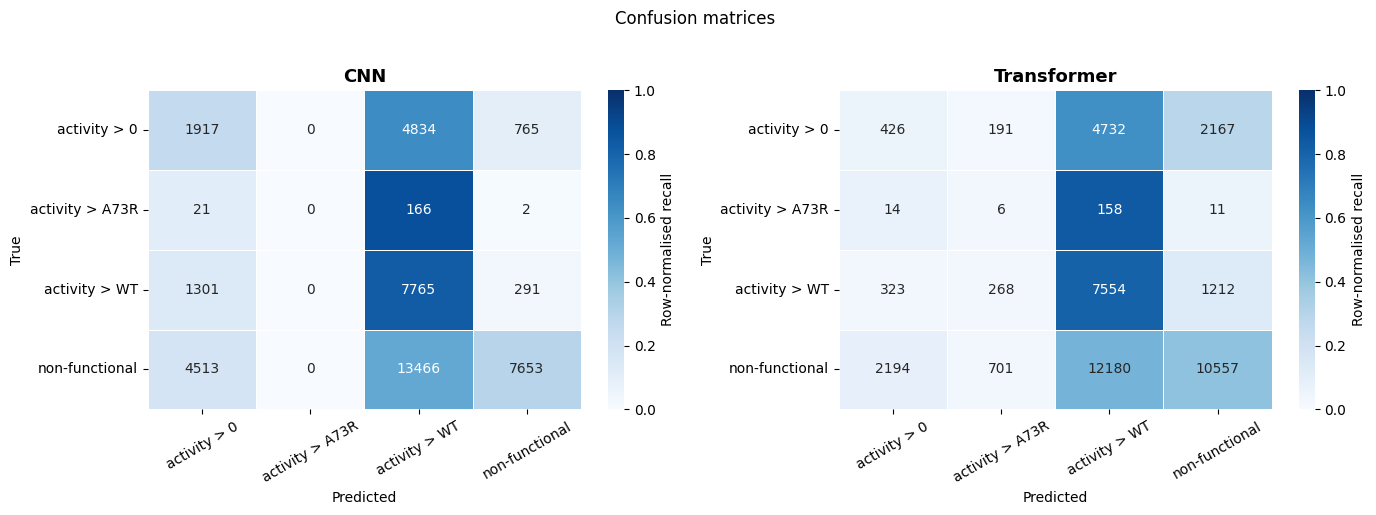

In [ ]:
# Confusion matrices (heat maps)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, df) in zip(axes, [("CNN", cnn_preds_df), ("Transformer", trans_preds_df)]):
    preds, labels = _to_indices(df)
    cm = confusion_matrix_df(preds, labels)
    # Normalise rows so each cell shows recall per true class
    cm_norm = cm.div(cm.sum(axis=1), axis=0)

    sns.heatmap(
        cm_norm,
        ax=ax,
        annot=cm.values,       # raw counts in each cell
        fmt="d",
        cmap="Blues",
        vmin=0, vmax=1,
        linewidths=0.5,
        cbar_kws={"label": "Row-normalised recall"},
    )
    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=30)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle("Confusion matrices", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Top-k accuracy (ordinal)
prob_cols = [f"prob_{cls}" for cls in ACTIVITY_CLASSES]

def topk_accuracy(df, ks):
    probs  = df[prob_cols].values                          # (N, 4)
    labels = np.array([ACTIVITY_CLASSES.index(c) for c in df["activity_level"]])
    # rank classes by descending probability for each sample
    ranked = np.argsort(-probs, axis=1)                    # (N, 4) — col 0 = top-1 class
    return [float(np.any(ranked[:, :k] == labels[:, None], axis=1).mean()) for k in ks]

ks = list(range(1, len(ACTIVITY_CLASSES) + 1))
cnn_topk   = topk_accuracy(cnn_preds_df,   ks)
trans_topk = topk_accuracy(trans_preds_df, ks)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ks, cnn_topk,   marker="o", linewidth=2, markersize=7, label="CNN")
ax.plot(ks, trans_topk, marker="s", linewidth=2, markersize=7, label="Transformer")

for k, acc in zip(ks, cnn_topk):
    ax.annotate(f"{acc:.3f}", xy=(k, acc), xytext=(-18, 6),
                textcoords="offset points", fontsize=8, color="C0")
for k, acc in zip(ks, trans_topk):
    ax.annotate(f"{acc:.3f}", xy=(k, acc), xytext=(4, 6),
                textcoords="offset points", fontsize=8, color="C1")

ax.set_xticks(ks)
ax.set_xticklabels([f"k={k}" for k in ks])
ax.set_xlabel("k  (true class in top-k by predicted probability)")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.08)
ax.set_title("Top-k accuracy — CNN vs Transformer", fontsize=12)
ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# Top-k accuracy (hit rate)
def topk_hit_rate_curve(df, n_points=300):
    probs    = df[prob_cols].values
    pred_idx = np.array([ACTIVITY_CLASSES.index(c) for c in df["predicted_class"]])
    true_idx = np.array([ACTIVITY_CLASSES.index(c) for c in df["activity_level"]])

    # confidence = probability the model assigned to its own predicted class
    confidence = probs[np.arange(len(df)), pred_idx]

    # sort sequences from most to least confident
    order       = np.argsort(-confidence)
    pred_sorted = pred_idx[order]
    true_sorted = true_idx[order]

    n  = len(df)
    ks = np.unique(np.linspace(1, n, n_points).astype(int))
    rates = [hit_rate(pred_sorted[:k], true_sorted[:k]) for k in ks]
    return ks / n, np.array(rates)

frac_cnn,   hr_cnn   = topk_hit_rate_curve(cnn_preds_df)
frac_trans, hr_trans = topk_hit_rate_curve(trans_preds_df)

# overall hit rate (all sequences) for reference lines
overall_hr_cnn   = hit_rate(*_to_indices(cnn_preds_df)[::-1])  # hit_rate(preds, labels)
overall_hr_trans = hit_rate(*_to_indices(trans_preds_df)[::-1])

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(frac_cnn,   hr_cnn,   linewidth=2, label="CNN")
ax.plot(frac_trans, hr_trans, linewidth=2, label="Transformer")
ax.axhline(overall_hr_cnn,   color="C0", linestyle="--", linewidth=1,
           label=f"CNN overall ({overall_hr_cnn:.3f})")
ax.axhline(overall_hr_trans, color="C1", linestyle="--", linewidth=1,
           label=f"Transformer overall ({overall_hr_trans:.3f})")

ax.set_xlabel("Fraction of test set retained (ranked by prediction confidence)")
ax.set_ylabel("Hit rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)
ax.set_title("Top-k hit rate vs. confidence threshold", fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# t-SNE of learned representations

BATCH_SIZE = 512

def extract_embeddings(model, sequences, batch_size=BATCH_SIZE, is_cnn=False):
    """Run sequences through model in batches, return (N, d) embedding matrix."""
    all_embs = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(sequences), batch_size):
            batch_seqs = sequences[i : i + batch_size]
            tokens = torch.tensor(
                [tokenize(s) for s in batch_seqs], dtype=torch.long
            )
            _, emb = model(tokens, return_embeddings=True)
            all_embs.append(emb.numpy())
    return np.concatenate(all_embs, axis=0)

# Load models
model_trans, _ = load_checkpoint('checkpoints/training_trans/epoch_046_acc0.6746.pt')
model_cnn,   _ = cnn_load_checkpoint('checkpoints/training_cnn/epoch_023_acc0.6700.pt')

seqs       = trans_preds_df["sequence"].tolist()   # same test split for both
true_labels = trans_preds_df["activity_level"].tolist()

print("Extracting transformer embeddings…")
emb_trans = extract_embeddings(model_trans, seqs)   # (N, 128)
print("Extracting CNN embeddings…")
emb_cnn   = extract_embeddings(model_cnn,   seqs, is_cnn=True)  # (N, 4544)

# PCA → 50 dims before t-SNE (standard practice; especially helpful for CNN's large space)
print("Running PCA + t-SNE…")
pca_trans = PCA(n_components=50, random_state=42).fit_transform(emb_trans)
pca_cnn   = PCA(n_components=50, random_state=42).fit_transform(emb_cnn)

tsne       = TSNE(n_components=2, perplexity=40, random_state=42, n_jobs=-1)
tsne_trans = tsne.fit_transform(pca_trans)
tsne_cnn   = tsne.fit_transform(pca_cnn)

# Plot
CLASS_COLORS = {cls: f"C{i}" for i, cls in enumerate(ACTIVITY_CLASSES)}
colors = [CLASS_COLORS[c] for c in true_labels]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (name, coords) in zip(axes, [("Transformer", tsne_trans), ("CNN", tsne_cnn)]):
    for cls in ACTIVITY_CLASSES:
        mask = np.array(true_labels) == cls
        ax.scatter(
            coords[mask, 0], coords[mask, 1],
            c=CLASS_COLORS[cls], label=cls,
            s=2, alpha=0.4, rasterized=True,
        )
    ax.set_title(name, fontsize=13, fontweight="bold")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend(markerscale=5, fontsize=8, loc="best")

fig.suptitle("t-SNE of learned representations — coloured by true activity class", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# attention maps to show which residue positions the transformer attends to most strongly.
# will take a while to run

# Load transformer checkpoint (needed for attention weights — not in saved CSV)
model_trans, _ = load_checkpoint('checkpoints/training_trans/epoch_046_acc0.6746.pt')
model_trans.eval()

# Pick one sequence — change the index to explore different variants
sample = trans_preds_df.iloc[0]
tokens = torch.tensor([tokenize(sample["sequence"])], dtype=torch.long)  # (1, seq_len)

with torch.no_grad():
    _, attn_list = model_trans(tokens, return_attention=True)
# attn_list: one (1, seq_len, seq_len) per layer, averaged over heads by nn.MultiheadAttention

seq_len  = tokens.shape[1]
n_layers = len(attn_list)

# --- per-layer attention maps ---
fig, axes = plt.subplots(1, n_layers, figsize=(6 * n_layers, 5))
if n_layers == 1:
    axes = [axes]

for ax, (layer_idx, attn) in zip(axes, enumerate(attn_list)):
    weights = attn[0].numpy()  # (seq_len, seq_len)
    im = ax.imshow(weights, cmap="viridis", aspect="auto")
    ax.set_title(f"Layer {layer_idx + 1}", fontsize=11)
    ax.set_xlabel("Key position (attended to)")
    ax.set_ylabel("Query position")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

true_cls = sample["activity_level"]
pred_cls = sample["predicted_class"]
fig.suptitle(
    f"Attention maps — true: {true_cls}  |  predicted: {pred_cls}\n"
    f"seq[:40]: {sample['sequence'][:40]}…",
    fontsize=10, y=1.02,
)
plt.tight_layout()
plt.show()

# --- per-residue importance: column-sum of last layer ---
last_layer     = attn_list[-1][0].numpy()       # (seq_len, seq_len)
pos_importance = last_layer.sum(axis=0)         # total attention received per position

fig2, ax2 = plt.subplots(figsize=(14, 3))
ax2.bar(range(seq_len), pos_importance, color="steelblue", width=1.0)
ax2.set_xlabel("Residue position")
ax2.set_ylabel("Total attention received (last layer)")
ax2.set_title("Per-residue attention — last layer")
ax2.set_xlim(0, seq_len)
plt.tight_layout()
plt.show()